## Figure S1 plots
Also includes code to write out the supplementary tables for benchmark dataset, benchmark alignment results, and benchmark clustering results

In [31]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from results_processing import format_foldseek_results, format_ialign_results, results_to_pairwise, roc1, roc1_auc_score, calculate_auc, create_heatmap, process_cluster_report, process_cluster_tsv, assign_nested_clusters

pd.options.mode.copy_on_write = True

# Global plot formatting
plt.rcParams['axes.spines.top'] = False # remove top spine
plt.rcParams['axes.spines.right'] = False # remove right spine
plt.rcParams['pdf.fonttype'] = 42 # Set the fonttype to export fonts as font files
plt.rcParams['font.family'] = 'Arial'
sns.set_palette("colorblind")
global_fontsize = 12
global_color = 'tab:grey'

In [2]:
def add_ground_truth(df, annotations):
    merge = pd.merge(df, annotations[['fullID','trueClusters','pairID','ClusterID']], left_on='query', right_on='fullID', how='left').drop('fullID',axis=1)
    merge.rename(columns={'trueClusters':'if1clust','pairID':'pfamID1','ClusterID':'pfamclust1'}, inplace=True)
    merge2 = pd.merge(merge, annotations[['fullID','trueClusters','pairID','ClusterID']], left_on='target', right_on='fullID', how='left').drop('fullID',axis=1)
    merge2.rename(columns={'trueClusters':'if2clust','pairID':'pfamID2','ClusterID':'pfamclust2'}, inplace=True)

    # Create agreement label to distinguish 'similar' from 'dissimilar' interfaces based on cluster assignment
    merge2.loc[merge2['if1clust'] == merge2['if2clust'], 'agreement'] = 1
    merge2['agreement'] = merge2['agreement'].fillna(0)

    return merge2

In [ ]:
def assess_benchmark(filepath1, filepath2, annotations):
    
    tsv1 = process_cluster_tsv(filepath1, dimer=True)
    tsv2 = process_cluster_tsv(filepath2, dimer=True)

    tsv2["predClust"] = pd.factorize(tsv2.representative)[0]

    assign_nested_clusters(tsv1, tsv2, clust_var="predClust")

    tsv1["trueClust"] = tsv1["member"].map(dict(zip(annotations.fullID, annotations.trueClusters)))

    return tsv1

In [3]:
pdb_clusters = pd.read_csv('/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv', sep='\t')
pdb_clusters['chain_id_0'] = pdb_clusters['chain_id_0'].fillna('NA')
pdb_clusters['chain_id_1'] = pdb_clusters['chain_id_1'].fillna('NA')
pdb_clusters['chains_sorted'] = pdb_clusters[['chain_id_0','chain_id_1']].apply(lambda x: '_'.join(sorted([str(y) for y in x])), axis=1)
pdb_clusters['full_lookup_id'] = pdb_clusters[['pdb_id','chain_id_0','chain_id_1']].apply(lambda x: '_'.join([str(y) for y in x]), axis=1)

pdb_clusters.loc[:,'simple_pdb_id'] = [x[:4] for x in pdb_clusters['pdb_id']]
pdb_clusters['full_lookup_id'] = pdb_clusters[['simple_pdb_id','chains_sorted']].apply(lambda x: '_'.join([str(y) for y in x]), axis=1)

ddi_clusters = pd.read_csv('/Volumes/imb-luckgr/projects/interface_clustering/datasets/benchmarking/ddi_clusters.csv')
ddi_clusters.loc[:,'chains'] = ddi_clusters[['chainA','chainB']].apply(lambda x: '_'.join(sorted([str(y) for y in x])), axis=1)
ddi_clusters.loc[:,'full_lookup_id'] = ddi_clusters[['PdbID','chains']].apply(lambda x: '_'.join([str(y) for y in x]), axis=1)
ddi_merge = pd.merge(ddi_clusters, pdb_clusters, on='full_lookup_id', how='left')

print(ddi_merge.shape[0])
print(ddi_merge.loc[ddi_merge['intcluster'].isna(),["PdbID","chains"]])
print(ddi_merge[ddi_merge["IFID"].duplicated(keep=False)])
ddi_merge.drop_duplicates(subset="IFID", keep="first", inplace=True)
print(ddi_merge[~ddi_merge["intcluster"].isna()].shape[0])

dmi_clusters = pd.read_csv('/Volumes/imb-luckgr/projects/interface_clustering/datasets/benchmarking/dmi_clusters.csv')
dmi_clusters.loc[:,'chains'] = dmi_clusters[['motif chain','domain chain']].apply(lambda x: '_'.join(sorted([str(y) for y in x])), axis=1)
dmi_clusters.loc[:,'full_lookup_id'] = dmi_clusters[['pdb_id','chains']].apply(lambda x: '_'.join([str(y) for y in x]), axis=1)
dmi_merge = pd.merge(dmi_clusters, pdb_clusters, on='full_lookup_id', how='left')

print(dmi_merge.shape[0])
print(dmi_merge.loc[dmi_merge['intcluster'].isna(),["pdb_id_x","chains"]])
print(dmi_merge.loc[dmi_merge["IFID"].duplicated(keep=False), ["pdb_id_y","intcluster", "chains"]])
dmi_merge.drop_duplicates(subset="IFID", keep="first", inplace=True)
print(dmi_merge[~dmi_merge["intcluster"].isna()].shape[0])

/var/folders/8n/b4ym5rbn48v7d2lxw_5ph7z40000gp/T/ipykernel_93581/2066216971.py:1: DtypeWarning: Columns (32,34) have mixed types. Specify dtype option on import or set low_memory=False.
  pdb_clusters = pd.read_csv('/Volumes/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv', sep='\t')


676
    PdbID chains
5    1ofi    C_M
133  6mze    B_S
227  5c3j    A_F
228  4ysy    A_F
229  4ysz    A_F
230  4ytm    A_F
231  4ysx    A_F
232  3vr8    A_F
233  3vra    A_F
234  4ytn    A_F
235  3vrb    A_F
236  3vr9    B_E
237  5xmj    I_N
238  5c3j    B_E
239  4ysy    B_E
240  4ysz    B_E
241  4ytm    B_E
242  5c2t    B_E
243  4yt0    B_E
244  4ytn    B_E
245  4ysx    B_E
246  3vr8    B_E
247  3vrb    B_E
248  3vra    B_E
249  3vr9    A_F
544  6bca    A_F
570  6zft    B_F
571  6haw    B_F
572  6zfu    B_F
589  5okd    B_F
590  6xvf    B_F
591  6zfs    B_F
592  7r3v    B_F
594  4d6u    B_S
595  4d6t    B_S
597  4pd4    B_G
601  1ezv    B_F
602  1kb9    B_G
603  1p84    B_G
604  2ibz    B_F
605  2bcc    B_F
608  1bcc    B_F
623  3bcc    B_F
653  7jrd    A_B
666  3jaq    k_l
                        pairID  Relation  ClusterID  CFID  SpaceGroup  \
6       (ACP)(Mal_decarbox_Al)     24217          1   1.0         P 1   
7       (ACP)(Mal_decarbox_Al)     24217          1   1.0         P 

## Supplemental table - benchmark dataset

In [4]:
ddi_merge_tocsv = ddi_merge[["IFID","PdbID","chainA","chainB","pairID","ClusterID","trueClusters","maxiflen","miniflen","maxdisfrac","mindisfrac"]]
ddi_merge_tocsv.rename(columns={"PdbID":"pdb_id", "chainA":"chainid_0", "chainB":"chainid_1", "pairID":"protcid_pfam_pair", "ClusterID":"protcid_pfam_cluster_id", "trueClusters":"ground_truth_cluster_id"}, inplace=True)
ddi_merge_tocsv.to_csv("/Volumes/imb-luckgr/projects/interface_clustering/datasets/supplemental_tables/order_order_benchmark_dataset.csv", index=None)

dmi_merge_tocsv = dmi_merge[["IFID","pdb_id_x","domain chain","motif chain","pfam_names","elm_identifier","trueClusters","maxiflen","miniflen","maxdisfrac","mindisfrac"]]
dmi_merge_tocsv.rename(columns={"pdb_id_x":"pdb_id", "domain chain":"chainid_0", "motif chain":"chainid_1", "pfam_names":"domain_pfam", "elm_identifier":"motif_elm_class", "trueClusters":"ground_truth_cluster_id"}, inplace=True)
dmi_merge_tocsv.to_csv("/Volumes/imb-luckgr/projects/interface_clustering/datasets/supplemental_tables/disorder_order_benchmark_dataset.csv", index=None)

## Panel a

In [5]:
ddi_merge['Dataset'] = "Order-\norder"
dmi_merge['Dataset'] = "Disorder-\norder"
bm_disfracs = pd.concat([ddi_merge[['Dataset','full_lookup_id','maxdisfrac','mindisfrac','maxiflen','miniflen']],
                         dmi_merge[['Dataset','full_lookup_id','maxdisfrac','mindisfrac','maxiflen','miniflen']]],
                         axis=0, ignore_index=True)
bm_disfracs = pd.melt(bm_disfracs, id_vars=['full_lookup_id','Dataset'], value_vars=['maxdisfrac','mindisfrac','maxiflen','miniflen'])
print(bm_disfracs.head())

  full_lookup_id        Dataset    variable  value
0       1g3i_A_G  Order-\norder  maxdisfrac  0.188
1       1kyi_A_G  Order-\norder  maxdisfrac  0.176
2       1ofh_A_G  Order-\norder  maxdisfrac  0.150
3       1ofi_A_G  Order-\norder  maxdisfrac  0.000
4       1g4b_F_M  Order-\norder  maxdisfrac  0.273


/var/folders/8n/b4ym5rbn48v7d2lxw_5ph7z40000gp/T/ipykernel_93581/2213879473.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dmi_merge['Dataset'] = "Disorder-\norder"


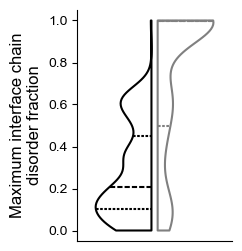

In [6]:
fig, ax = plt.subplots(figsize=(2,3))
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
sns.violinplot(data=bm_disfracs[(bm_disfracs['variable'] == 'maxdisfrac')], x='variable', y='value', hue='Dataset', fill=None, split=True, inner="quart", cut=0, gap=0.1, palette=["black","gray"], ax=ax, legend=False)
ax.set_xticks([])
ax.set_xlabel(None)
ax.set_ylabel("Maximum interface chain\ndisorder fraction", fontsize=12)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/bmark_disorder_comparison.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/bmark_disorder_comparison.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

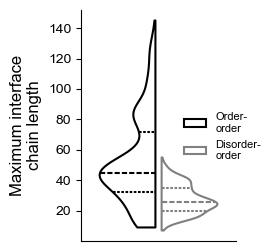

In [7]:
fig, ax = plt.subplots(figsize=(2,3))
ax.spines.top.set_visible(False)
ax.spines.right.set_visible(False)
sns.violinplot(data=bm_disfracs[(bm_disfracs['variable'] == 'maxiflen')], x='variable', y='value', hue='Dataset', fill=None, split=True, inner="quart", cut=0, gap=0.1, palette=["black","gray"], ax=ax)
ax.set_xticks([])
ax.set_xlabel(None)
ax.set_ylabel("Maximum interface\nchain length", fontsize=12)
ax.legend(loc=0, bbox_to_anchor=(0.6,0.6), frameon=False, fontsize=8)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/bmark_iflen_comparison.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/bmark_iflen_comparison.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

In [8]:
ddi_disfracs = [x for x in list(bm_disfracs[((bm_disfracs['variable'] == 'maxdisfrac') & (bm_disfracs["Dataset"] == "Order-\norder"))]["value"]) if x >= 0]
dmi_disfracs = [x for x in list(bm_disfracs[((bm_disfracs['variable'] == 'maxdisfrac') & (bm_disfracs["Dataset"] == "Disorder-\norder"))]["value"]) if x >= 0]
print(scipy.stats.mannwhitneyu(ddi_disfracs, dmi_disfracs))

ddi_iflens = [x for x in list(bm_disfracs[((bm_disfracs['variable'] == 'maxiflen') & (bm_disfracs["Dataset"] == "Order-\norder"))]["value"]) if x >= 0]
dmi_iflens = [x for x in list(bm_disfracs[((bm_disfracs['variable'] == 'maxiflen') & (bm_disfracs["Dataset"] == "Disorder-\norder"))]["value"]) if x >= 0]
print(scipy.stats.mannwhitneyu(ddi_iflens, dmi_iflens))

MannwhitneyuResult(statistic=52349.5, pvalue=2.1283301483770574e-78)
MannwhitneyuResult(statistic=372679.0, pvalue=1.3063330048626154e-76)


## Panel b

In [9]:
ddi_order = list(ddi_clusters.fullID)
ddi_structures = list(set(ddi_clusters.fullID))
ddi_cluster_assignments = dict(zip(ddi_clusters.fullID, ddi_clusters.full_clusterID))

dmi_order = list(dmi_clusters.fullID)
dmi_structures = list(set(dmi_clusters.fullID))
dmi_cluster_assignments = dict(zip(dmi_clusters.fullID, dmi_clusters.elm_identifier))

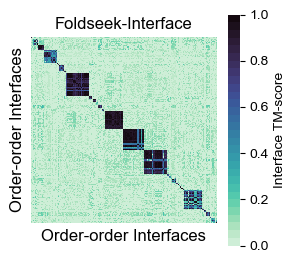

In [ ]:
ddi_fsdata = format_foldseek_results('/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/benchmark_alignment/foldseek_ddi_aln_report')
results_ddi, frac_aligned = results_to_pairwise(ddi_fsdata, ['qscore','tscore'], ddi_structures, ddi_cluster_assignments)
auc, auroc = calculate_auc(results_ddi, ddi_structures)
print("Results for alignment of DDI dataset:", "\nAUC: ", auc, "\nAUROC: ", auroc)

alignments = results_ddi.pivot_table(index='if1',columns='if2',values='avg')
alignments = alignments.reindex(ddi_order)
alignments = alignments.reindex(columns=ddi_order)

# Final visualization with heatmap and dendrogram with output clusters labeled in color bars on left-hand side
palette = sns.color_palette("mako", n_colors=30)
palette.reverse()
fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(alignments, vmin=0.00, vmax=1.00, yticklabels=False, xticklabels=False, ax=ax, square=True, cmap=palette, cbar_kws={"label":"Interface TM-score"})
ax.set_xlabel("Order-order Interfaces", fontsize=12)
ax.set_ylabel("Order-order Interfaces", fontsize=12)
ax.set_title("Foldseek-Interface")

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/foldseek_ddi_heatmap.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/foldseek_ddi_heatmap.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

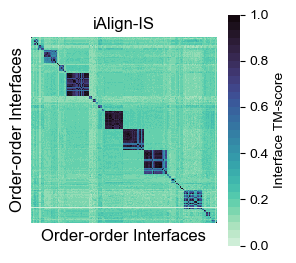

In [ ]:
ddi_ialn_isdata = format_ialign_results('/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/benchmark_alignment/ialign-is_ddi_output.txt')
results_is_ddi, frac_aligned = results_to_pairwise(ddi_ialn_isdata, ['score'], ddi_structures, ddi_cluster_assignments)
auc, auroc = calculate_auc(results_is_ddi, ddi_structures)
print("Results for alignment of DDI dataset:", "\nAUC: ", auc, "\nAUROC: ", auroc)

alignments = results_is_ddi.pivot_table(index='if1',columns='if2',values='avg')
alignments = alignments.reindex(ddi_order)
alignments = alignments.reindex(columns=ddi_order)

# Final visualization with heatmap and dendrogram with output clusters labeled in color bars on left-hand side
palette = sns.color_palette("mako", n_colors=30)
palette.reverse()
fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(alignments, vmin=0.00, vmax=1.00, yticklabels=False, xticklabels=False, ax=ax, square=True, cmap=palette, cbar_kws={"label":"Interface TM-score"})
ax.set_xlabel("Order-order Interfaces", fontsize=12)
ax.set_ylabel("Order-order Interfaces", fontsize=12)
ax.set_title("iAlign-IS")

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/ialign-is_ddi_heatmap.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/ialign-is_ddi_heatmap.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

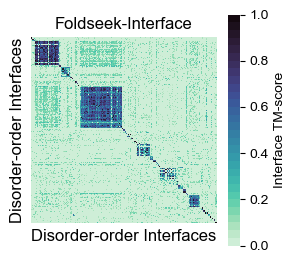

In [ ]:
dmi_fsdata = format_foldseek_results('/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/benchmark_alignment/foldseek_dmi_aln_report')
results_dmi, frac_aligned = results_to_pairwise(dmi_fsdata, ['qscore','tscore'], dmi_structures, dmi_cluster_assignments)
auc, auroc = calculate_auc(results_dmi, dmi_structures)
print("Results for alignment of DMI dataset:", "\nAUC: ", auc, "\nAUROC: ", auroc)

alignments = results_dmi.pivot_table(index='if1',columns='if2',values='avg')
alignments = alignments.reindex(dmi_order)
alignments = alignments.reindex(columns=dmi_order)

# Final visualization with heatmap and dendrogram with output clusters labeled in color bars on left-hand side
palette = sns.color_palette("mako", n_colors=30)
palette.reverse()
fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(alignments, vmin=0.00, vmax=1.00, yticklabels=False, xticklabels=False, ax=ax, square=True, cmap=palette, cbar_kws={"label":"Interface TM-score"})
ax.set_xlabel("Disorder-order Interfaces", fontsize=12)
ax.set_ylabel("Disorder-order Interfaces", fontsize=12)
ax.set_title("Foldseek-Interface")

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/foldseek_dmi_heatmap.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/foldseek_dmi_heatmap.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

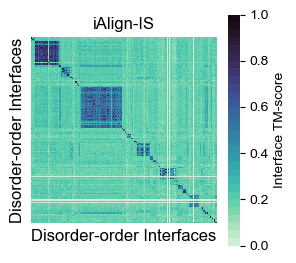

In [ ]:
dmi_ialn_isdata = format_ialign_results('/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/benchmark_alignment/ialign-is_dmi_output.txt')
results_is_dmi, frac_aligned = results_to_pairwise(dmi_ialn_isdata, ['score'], dmi_structures, dmi_cluster_assignments)
auc, auroc = calculate_auc(results_is_dmi, dmi_structures)
print("Results for alignment of DMI dataset:", "\nAUC: ", auc, "\nAUROC: ", auroc)

alignments = results_is_dmi.pivot_table(index='if1',columns='if2',values='avg')
alignments = alignments.reindex(dmi_order)
alignments = alignments.reindex(columns=dmi_order)

# Final visualization with heatmap and dendrogram with output clusters labeled in color bars on left-hand side
palette = sns.color_palette("mako", n_colors=30)
palette.reverse()
fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(alignments, vmin=0.00, vmax=1.00, yticklabels=False, xticklabels=False, ax=ax, square=True, cmap=palette, cbar_kws={"label":"Interface TM-score"})
ax.set_xlabel("Disorder-order Interfaces", fontsize=12)
ax.set_ylabel("Disorder-order Interfaces", fontsize=12)
ax.set_title("iAlign-IS")

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/ialign-is_dmi_heatmap.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/ialign-is_dmi_heatmap.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel c

In [ ]:
ddi_ialn_tmdata = format_ialign_results('/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/benchmark_alignment/ialign-tm_ddi_output.txt')
results_tm_ddi, frac_aligned = results_to_pairwise(ddi_ialn_tmdata, ['score'], ddi_structures, ddi_cluster_assignments)
auc, auroc = calculate_auc(results_tm_ddi, ddi_structures)
print("Results for alignment of DDI dataset:", "\nAUC: ", auc, "\nAUROC: ", auroc)
dmi_ialn_tmdata = format_ialign_results('/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/benchmark_alignment/ialign-tm_dmi_output.txt')
results_tm_dmi, frac_aligned = results_to_pairwise(dmi_ialn_tmdata, ['score'], dmi_structures, dmi_cluster_assignments)
auc, auroc = calculate_auc(results_tm_dmi, dmi_structures)
print("Results for alignment of DMI dataset:", "\nAUC: ", auc, "\nAUROC: ", auroc)

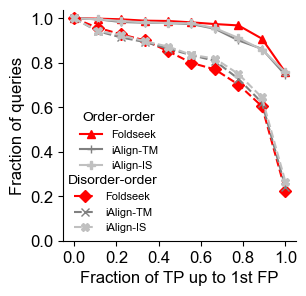

In [15]:
results_ddi.sort_values(by='avg', ascending=False, inplace=True)
results_is_ddi.sort_values(by='avg', ascending=False, inplace=True)
results_tm_ddi.sort_values(by='avg', ascending=False, inplace=True)

fs_fracs_ddi = results_ddi.groupby('if1').apply(roc1, include_groups=False)
is_fracs_ddi = results_is_ddi.groupby('if1').apply(roc1, include_groups=False)
tm_fracs_ddi = results_tm_ddi.groupby('if1').apply(roc1, include_groups=False)

thresh = np.linspace(0.0, 1.0, 10)

fsdf_roc1_ddi = []
isdf_roc1_ddi = []
tmdf_roc1_ddi = []
for n in thresh:
    fsdf_roc1_ddi.append(sum(fs_fracs_ddi >= n)/len(fs_fracs_ddi))
    isdf_roc1_ddi.append(sum(is_fracs_ddi >= n)/len(is_fracs_ddi))
    tmdf_roc1_ddi.append(sum(tm_fracs_ddi >= n)/len(tm_fracs_ddi))

results_dmi.sort_values(by='avg', ascending=False, inplace=True)
results_is_dmi.sort_values(by='avg', ascending=False, inplace=True)
results_tm_dmi.sort_values(by='avg', ascending=False, inplace=True)

fs_fracs_dmi = results_dmi.groupby('if1').apply(roc1, include_groups=False)
is_fracs_dmi = results_is_dmi.groupby('if1').apply(roc1, include_groups=False)
tm_fracs_dmi = results_tm_dmi.groupby('if1').apply(roc1, include_groups=False)

fsdf_roc1_dmi = []
isdf_roc1_dmi = []
tmdf_roc1_dmi = []
for n in thresh:
    fsdf_roc1_dmi.append(sum(fs_fracs_dmi >= n)/len(fs_fracs_dmi))
    isdf_roc1_dmi.append(sum(is_fracs_dmi >= n)/len(is_fracs_dmi))
    tmdf_roc1_dmi.append(sum(tm_fracs_dmi >= n)/len(tm_fracs_dmi))

legend_elements_ddi = [mpl.lines.Line2D([0], [0], color='red', marker='^', linestyle="solid", label='Foldseek'),
                       mpl.lines.Line2D([0], [0], color='gray', marker='+', linestyle="solid", label="iAlign-TM"),
                       mpl.lines.Line2D([0], [0], color='silver', marker='P', linestyle="solid", label='iAlign-IS')]
legend_elements_dmi = [mpl.lines.Line2D([0], [0], color='red', marker='D', linestyle="dashed", label='Foldseek'),
                       mpl.lines.Line2D([0], [0], color='gray', marker='x', linestyle="dashed", label="iAlign-TM"),
                       mpl.lines.Line2D([0], [0], color='silver', marker='X', linestyle="dashed", label='iAlign-IS')]

fig, ax = plt.subplots(figsize=(3,3))
ax.plot(thresh,fsdf_roc1_ddi, color='red', marker="^", linestyle="solid")
ax.plot(thresh,tmdf_roc1_ddi, color='gray', marker="+", linestyle="solid")
ax.plot(thresh,isdf_roc1_ddi, color='silver', marker="P", linestyle="solid")
ax.plot(thresh,fsdf_roc1_dmi, color='red', marker="D", linestyle='dashed')
ax.plot(thresh,tmdf_roc1_dmi, color='gray', marker="x", linestyle='dashed')
ax.plot(thresh,isdf_roc1_dmi, color='silver', marker="X", linestyle='dashed')
ax.tick_params(axis= 'both', labelsize= global_fontsize)
ax.set_xlabel('Fraction of TP up to 1st FP', fontsize=global_fontsize)
ax.set_ylabel('Fraction of queries', fontsize=global_fontsize)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
legend1 = plt.legend(handles=legend_elements_ddi, loc=0, bbox_to_anchor=(0.45,0.6), frameon=False, title="Order-order", fontsize=8)
ax.legend(handles=legend_elements_dmi, loc=0, bbox_to_anchor=(0.45,0.33), frameon=False, title="Disorder-order", fontsize=8)
ax.add_artist(legend1)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/bmark_ROC1.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/bmark_ROC1.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Supplemental table - alignment results

In [30]:
results_ddi_tocsv = results_ddi.rename(columns={"avg":"fs-if_avg_tmscore"})
results_is_ddi_tocsv = results_is_ddi.rename(columns={"avg":"ialn_avg_isscore"})
results_tm_ddi_tocsv = results_tm_ddi.rename(columns={"avg":"ialn_avg_tmscore"})
results_ialn_ddi_tocsv = pd.merge(results_is_ddi_tocsv, results_tm_ddi_tocsv[["if1","if2","ialn_avg_tmscore"]], on=["if1","if2"], how="outer")
results_ddi_tocsv = pd.merge(results_ialn_ddi_tocsv, results_ddi_tocsv[["if1","if2","fs-if_avg_tmscore"]], on=["if1","if2"], how="outer")
results_ddi_tocsv = results_ddi_tocsv[["if1","if2","fs-if_avg_tmscore","ialn_avg_tmscore","ialn_avg_isscore","cluster1","cluster2","agreement"]]
results_ddi_tocsv.rename(columns={"agreement":"same_cluster"}, inplace=True)
results_ddi_tocsv.to_csv("/Volumes/imb-luckgr/projects/interface_clustering/datasets/supplemental_tables/order_order_alignment_results.csv", index=None)

results_dmi_tocsv = results_dmi.rename(columns={"avg":"fs-if_avg_tmscore"})
results_is_dmi_tocsv = results_is_dmi.rename(columns={"avg":"ialn_avg_isscore"})
results_tm_dmi_tocsv = results_tm_dmi.rename(columns={"avg":"ialn_avg_tmscore"})
results_ialn_dmi_tocsv = pd.merge(results_is_dmi_tocsv, results_tm_dmi_tocsv[["if1","if2","ialn_avg_tmscore"]], on=["if1","if2"], how="outer")
results_dmi_tocsv = pd.merge(results_ialn_dmi_tocsv, results_dmi_tocsv[["if1","if2","fs-if_avg_tmscore"]], on=["if1","if2"], how="outer")
results_dmi_tocsv = results_dmi_tocsv[["if1","if2","fs-if_avg_tmscore","ialn_avg_tmscore","ialn_avg_isscore","cluster1","cluster2","agreement"]]
results_dmi_tocsv.rename(columns={"agreement":"same_cluster"}, inplace=True)
results_dmi_tocsv.to_csv("/Volumes/imb-luckgr/projects/interface_clustering/datasets/supplemental_tables/disorder_order_alignment_results.csv", index=None)

## Supplemental table - clustering results

In [40]:
ddi_path = "/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/benchmark_cluster/"
ddi_nested_clust = assess_benchmark(filepath1 = ddi_path+"ddidimer_cluster.tsv",
                       filepath2 = ddi_path+"ddidimerrepint_0.3_cluster.tsv",
                       annotations = ddi_clusters)
ddi_clust_tocsv = ddi_nested_clust.drop(["representative"], axis=1)
ddi_clust_tocsv.rename(columns={"member":"if", "parent_clust":"fs-if-clust_assignment", "trueClust":"ground_truth_cluster_id"}, inplace=True)
ddi_clust_tocsv["ground_truth_cluster_name"] = ddi_clust_tocsv["if"].map(ddi_cluster_assignments)
ddi_clust_tocsv["pdb_cluster_assignment"] = ddi_clust_tocsv["if"].map(dict(zip(ddi_merge["fullID"], ddi_merge["intcluster"])))
ddi_clust_tocsv.to_csv("/Volumes/imb-luckgr/projects/interface_clustering/datasets/supplemental_tables/order_order_clustering_results.csv", index=None)

dmi_path = "/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/benchmark_cluster/"
dmi_nested_clust = assess_benchmark(filepath1 = dmi_path+"dmidimer_cluster.tsv",
                       filepath2 = dmi_path+"dmidimerrepint_0.3_cluster.tsv",
                       annotations = dmi_clusters)
dmi_clust_tocsv = dmi_nested_clust.drop(["representative"], axis=1)
dmi_clust_tocsv.rename(columns={"member":"if", "parent_clust":"fs-if-clust_assignment", "trueClust":"ground_truth_cluster_id"}, inplace=True)
dmi_clust_tocsv["ground_truth_cluster_name"] = dmi_clust_tocsv["if"].map(dmi_cluster_assignments)
dmi_clust_tocsv["pdb_cluster_assignment"] = dmi_clust_tocsv["if"].map(dict(zip(dmi_merge["fullID"], dmi_merge["intcluster"])))
dmi_clust_tocsv.to_csv("/Volumes/imb-luckgr/projects/interface_clustering/datasets/supplemental_tables/disorder_order_clustering_results.csv", index=None)

## Panel d

In [33]:
ddi_lddtthresh_df = format_foldseek_results("/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/test_scaling/ddi_pdb-plus-bm_aln_lddt-thresh_report_filtered", version='new')
ddi_lddtthresh_df, frac_aligned = results_to_pairwise(ddi_lddtthresh_df, ['qscore','tscore'], ddi_structures, ddi_cluster_assignments)
ddi_lddtthresh_df = ddi_lddtthresh_df.sort_values(by='avg', ascending=False)
ddi_noexhaust_df = format_foldseek_results("/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/test_scaling/ddi_pdb-plus-bm_aln_no-exhaust_report_filtered", version='new')
ddi_noexhaust_df, frac_aligned = results_to_pairwise(ddi_noexhaust_df, ['qscore','tscore'], ddi_structures, ddi_cluster_assignments)
ddi_noexhaust_df = ddi_noexhaust_df.sort_values(by='avg', ascending=False)
ddi_ungapped_df = format_foldseek_results("/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/test_scaling/ddi_pdb-plus-bm_aln_ungapped_report_filtered", version='new')
ddi_ungapped_df, frac_aligned = results_to_pairwise(ddi_ungapped_df, ['qscore','tscore'], ddi_structures, ddi_cluster_assignments)
ddi_ungapped_df = ddi_ungapped_df.sort_values(by='avg', ascending=False)

ddi_lddtthresh_fracs = ddi_lddtthresh_df.groupby('if1').apply(roc1, include_groups=False)
ddi_noexhaust_fracs = ddi_noexhaust_df.groupby('if1').apply(roc1, include_groups=False)
ddi_ungapped_fracs = ddi_ungapped_df.groupby('if1').apply(roc1, include_groups=False)

In [34]:
dmi_lddtthresh_df = format_foldseek_results("/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/test_scaling/dmi_pdb-plus-bm_aln_lddt-thresh_report_filtered", version='new')
dmi_lddtthresh_df, frac_aligned = results_to_pairwise(dmi_lddtthresh_df, ['qscore','tscore'], dmi_structures, dmi_cluster_assignments)
dmi_lddtthresh_df = dmi_lddtthresh_df.sort_values(by='avg', ascending=False)
dmi_noexhaust_df = format_foldseek_results("/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/test_scaling/dmi_pdb-plus-bm_aln_no-exhaust_report_filtered", version='new')
dmi_noexhaust_df, frac_aligned = results_to_pairwise(dmi_noexhaust_df, ['qscore','tscore'], dmi_structures, dmi_cluster_assignments)
dmi_noexhaust_df = dmi_noexhaust_df.sort_values(by='avg', ascending=False)
dmi_ungapped_df = format_foldseek_results("/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/test_scaling/dmi_pdb-plus-bm_aln_ungapped_report_filtered", version='new')
dmi_ungapped_df, frac_aligned = results_to_pairwise(dmi_ungapped_df, ['qscore','tscore'], dmi_structures, dmi_cluster_assignments)
dmi_ungapped_df = dmi_ungapped_df.sort_values(by='avg', ascending=False)

dmi_lddtthresh_fracs = dmi_lddtthresh_df.groupby('if1').apply(roc1, include_groups=False)
dmi_noexhaust_fracs = dmi_noexhaust_df.groupby('if1').apply(roc1, include_groups=False)
dmi_ungapped_fracs = dmi_ungapped_df.groupby('if1').apply(roc1, include_groups=False)

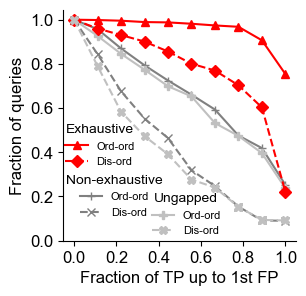

In [37]:
thresh = np.linspace(0.0, 1.0, 10)

ddi_lddtthresh_roc1 = []
ddi_noexhaust_roc1 = []
ddi_ungapped_roc1 = []
dmi_lddtthresh_roc1 = []
dmi_noexhaust_roc1 = []
dmi_ungapped_roc1 = []

for n in thresh:
    ddi_lddtthresh_roc1.append(sum(ddi_lddtthresh_fracs >= n)/len(ddi_lddtthresh_fracs))
    ddi_noexhaust_roc1.append(sum(ddi_noexhaust_fracs >= n)/len(ddi_noexhaust_fracs))
    ddi_ungapped_roc1.append(sum(ddi_ungapped_fracs >= n)/len(ddi_ungapped_fracs))
    dmi_lddtthresh_roc1.append(sum(dmi_lddtthresh_fracs >= n)/len(dmi_lddtthresh_fracs))
    dmi_noexhaust_roc1.append(sum(dmi_noexhaust_fracs >= n)/len(dmi_noexhaust_fracs))
    dmi_ungapped_roc1.append(sum(dmi_ungapped_fracs >= n)/len(dmi_ungapped_fracs))

legend_elements_lddtthresh = [mpl.lines.Line2D([0], [0], color='red', marker='^', linestyle="solid", label="Ord-ord"),
                       mpl.lines.Line2D([0], [0], color='red', marker='D', linestyle="dashed", label="Dis-ord")]
legend_elements_noexhaust = [mpl.lines.Line2D([0], [0], color='gray', marker='+', linestyle="solid", label="Ord-ord"),
                       mpl.lines.Line2D([0], [0], color='gray', marker='x', linestyle="dashed", label="Dis-ord")]
legend_elements_ungapped = [mpl.lines.Line2D([0], [0], color='silver', marker='P', linestyle="solid", label="Ord-ord"),
                       mpl.lines.Line2D([0], [0], color='silver', marker='X', linestyle="dashed", label="Dis-ord")]

fig, ax = plt.subplots(figsize=(3,3))
plt.plot(thresh, ddi_lddtthresh_roc1, color="red", marker="^", linestyle="solid")
plt.plot(thresh, ddi_noexhaust_roc1, color="gray", marker="+", linestyle="solid")
plt.plot(thresh, ddi_ungapped_roc1, color="silver", marker="P", linestyle="solid")
plt.plot(thresh, dmi_lddtthresh_roc1, color="red", marker="D", linestyle="dashed")
plt.plot(thresh, dmi_noexhaust_roc1, color="gray", marker="x", linestyle="dashed")
plt.plot(thresh, dmi_ungapped_roc1, color="silver", marker="X", linestyle="dashed")
ax.tick_params(axis= 'both', labelsize= 12)
ax.set_xlabel('Fraction of TP up to 1st FP', fontsize=12)
ax.set_ylabel('Fraction of queries', fontsize=12)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
legend1 = plt.legend(handles=legend_elements_lddtthresh, loc=0, bbox_to_anchor=(0.35,0.55), frameon=False, title="Exhaustive", fontsize=8)
legend2 = plt.legend(handles=legend_elements_noexhaust, loc=0, bbox_to_anchor=(0.47,0.33), frameon=False, title="Non-exhaustive", fontsize=8)
ax.legend(handles=legend_elements_ungapped, loc=0, bbox_to_anchor=(0.72,0.25), frameon=False, title="Ungapped", fontsize=8)
ax.add_artist(legend1)
ax.add_artist(legend2)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/bmark_filteringmethods.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/bmark_filteringmethods.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

## Panel e

In [38]:
fsdf = format_foldseek_results("/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/benchmark_alignment/foldseek_ddi_aln_report", version='new')
fsdf_merge = add_ground_truth(fsdf, ddi_clusters)
num_tp_baseline = sum(fsdf_merge.agreement)
num_fp_baseline = fsdf_merge.shape[0] - num_tp_baseline
print(num_tp_baseline)
print(num_fp_baseline)

31790.0
209235.0


In [39]:
all_scores = pd.DataFrame({'score':[], 'thresh':[], 'sensitivity':[], 'specificity':[], 'dataset':[]})
scores = ["lddt", "tmscore"]
threshs = [10, 20, 30, 40, 50, 60, 70, 80, 90]
for score in scores:
    curr_score = score
    for thresh in threshs:
        fsdf = format_foldseek_results(f"/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/test_scaling/ddi_{score}{str(thresh)}_report", version='new')
        fsdf_merge = add_ground_truth(fsdf, ddi_clusters)
        num_tp = sum(fsdf_merge.agreement)
        num_fp = fsdf_merge.shape[0] - num_tp
        sensitivity = num_tp / num_tp_baseline
        specificity = (num_fp_baseline - num_fp) / num_fp_baseline
        firstrow = pd.DataFrame({'score':score, 'thresh':str(thresh/100), 'sensitivity':sensitivity, 'specificity':specificity, 'dataset':"Ord-ord"}, index=[0])
        all_scores = pd.concat([all_scores, firstrow], ignore_index=True)

In [40]:
fsdf = format_foldseek_results("/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/benchmark_alignment/foldseek_dmi_aln_report", version='new')
fsdf_merge = add_ground_truth(fsdf, dmi_clusters)
num_tp_baseline = sum(fsdf_merge.agreement)
num_fp_baseline = fsdf_merge.shape[0] - num_tp_baseline
print(num_tp_baseline)
print(num_fp_baseline)

47218.0
215936.0


In [41]:
scores = ["lddt", "tmscore"]
threshs = [10, 20, 30, 40, 50, 60, 70, 80, 90]
for score in scores:
    curr_score = score
    for thresh in threshs:
        fsdf = format_foldseek_results(f"/Volumes/imb-luckgr/projects/interface_clustering/results/benchmarking/test_scaling/dmi_{score}{str(thresh)}_report", version='new')
        fsdf_merge = add_ground_truth(fsdf, dmi_clusters)
        num_tp = sum(fsdf_merge.agreement)
        num_fp = fsdf_merge.shape[0] - num_tp
        sensitivity = num_tp / num_tp_baseline
        specificity = (num_fp_baseline - num_fp) / num_fp_baseline
        firstrow = pd.DataFrame({'score':score, 'thresh':str(thresh/100), 'sensitivity':sensitivity, 'specificity':specificity, 'dataset':"Dis-ord"}, index=[0])
        all_scores = pd.concat([all_scores, firstrow], ignore_index=True)

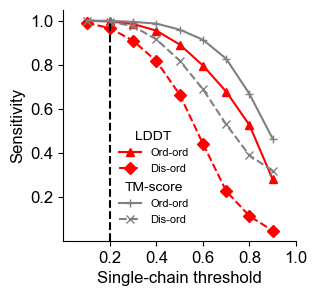

In [44]:
thresh_toplot = [x/100 for x in threshs]
ddi_lddt_sens = all_scores[((all_scores["dataset"] == "Ord-ord") & (all_scores["score"] == "lddt"))]["sensitivity"]
ddi_tm_sens = all_scores[((all_scores["dataset"] == "Ord-ord") & (all_scores["score"] == "tmscore"))]["sensitivity"]
dmi_lddt_sens = all_scores[((all_scores["dataset"] == "Dis-ord") & (all_scores["score"] == "lddt"))]["sensitivity"]
dmi_tm_sens = all_scores[((all_scores["dataset"] == "Dis-ord") & (all_scores["score"] == "tmscore"))]["sensitivity"]

legend_elements_lddt = [mpl.lines.Line2D([0], [0], color='red', marker='^', linestyle="solid", label="Ord-ord"),
                       mpl.lines.Line2D([0], [0], color='red', marker='D', linestyle="dashed", label="Dis-ord")]
legend_elements_tm = [mpl.lines.Line2D([0], [0], color='gray', marker='+', linestyle="solid", label="Ord-ord"),
                       mpl.lines.Line2D([0], [0], color='gray', marker='x', linestyle="dashed", label="Dis-ord")]

fig, ax = plt.subplots(figsize=(3,3))
ax.plot(thresh_toplot, ddi_lddt_sens, color="red", marker="^", linestyle="solid")
ax.plot(thresh_toplot, ddi_tm_sens, color="gray", marker="+", linestyle="solid")
ax.plot(thresh_toplot, dmi_lddt_sens, color="red", marker="D", linestyle="dashed")
ax.plot(thresh_toplot, dmi_tm_sens, color="gray", marker="x", linestyle="dashed")
ax.vlines(x=0.2, ymin=0, ymax=1, linestyle="dashed", color="black")
ax.set_ylim([0,1.05])
ax.set_xlim([0,1.0])
ax.tick_params(axis= 'both', labelsize= global_fontsize)
ax.set_xlabel('Single-chain threshold', fontsize=global_fontsize)
ax.set_ylabel('Sensitivity', fontsize=global_fontsize)
ax.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
legend1 = plt.legend(handles=legend_elements_lddt, loc=0, bbox_to_anchor=(0.58,0.52), frameon=False, title="LDDT", fontsize=8)
ax.legend(handles=legend_elements_tm, loc=0, bbox_to_anchor=(0.58,0.3), frameon=False, title="TM-score", fontsize=8)
ax.add_artist(legend1)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/bmark_chainthresh_sensitivity.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/bmark_chainthresh_sensitivity.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')

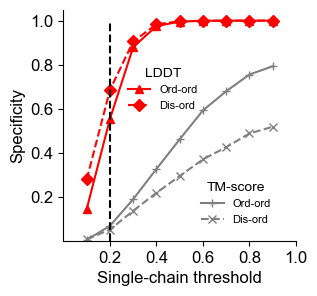

In [47]:
thresh_toplot = [x/100 for x in threshs]
ddi_lddt_spec = all_scores[((all_scores["dataset"] == "Ord-ord") & (all_scores["score"] == "lddt"))]["specificity"]
ddi_tm_spec = all_scores[((all_scores["dataset"] == "Ord-ord") & (all_scores["score"] == "tmscore"))]["specificity"]
dmi_lddt_spec = all_scores[((all_scores["dataset"] == "Dis-ord") & (all_scores["score"] == "lddt"))]["specificity"]
dmi_tm_spec = all_scores[((all_scores["dataset"] == "Dis-ord") & (all_scores["score"] == "tmscore"))]["specificity"]

legend_elements_lddt = [mpl.lines.Line2D([0], [0], color='red', marker='^', linestyle="solid", label="Ord-ord"),
                       mpl.lines.Line2D([0], [0], color='red', marker='D', linestyle="dashed", label="Dis-ord")]
legend_elements_tm = [mpl.lines.Line2D([0], [0], color='gray', marker='+', linestyle="solid", label="Ord-ord"),
                       mpl.lines.Line2D([0], [0], color='gray', marker='x', linestyle="dashed", label="Dis-ord")]

fig, ax = plt.subplots(figsize=(3,3))
ax.plot(thresh_toplot, ddi_lddt_spec, color="red", marker="^", linestyle="solid")
ax.plot(thresh_toplot, ddi_tm_spec, color="gray", marker="+", linestyle="solid")
ax.plot(thresh_toplot, dmi_lddt_spec, color="red", marker="D", linestyle="dashed")
ax.plot(thresh_toplot, dmi_tm_spec, color="gray", marker="x", linestyle="dashed")
ax.vlines(x=0.2, ymin=0, ymax=1, linestyle="dashed", color="black")
ax.set_ylim([0,1.05])
ax.set_xlim([0,1.0])
ax.tick_params(axis= 'both', labelsize= global_fontsize)
ax.set_xlabel('Single-chain threshold', fontsize=global_fontsize)
ax.set_ylabel('Specificity', fontsize=global_fontsize)
ax.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
legend1 = plt.legend(handles=legend_elements_lddt, loc=0, bbox_to_anchor=(0.62,0.52), frameon=False, title="LDDT", fontsize=8)
ax.legend(handles=legend_elements_tm, loc=0, bbox_to_anchor=(0.55,0.3), frameon=False, title="TM-score", fontsize=8)
ax.add_artist(legend1)

fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/bmark_chainthresh_specificity.pdf',
           transparent=True,bbox_inches='tight')
fig.savefig('/Volumes/imb-luckgr/projects/interface_clustering/visualizations/plots/bmark_chainthresh_specificity.jpeg',dpi=300,
           transparent=True,bbox_inches='tight')